<a href="https://colab.research.google.com/github/2303A52345/Mobile_price_prediction_project/blob/main/Mobile_Price_Prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
data = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")
print(df.head())
print(df.info())

   Ratings  RAM    ROM  Mobile_Size  Primary_Cam  Selfi_Cam  Battery_Power  \
0      4.3  4.0  128.0         6.00           48       13.0           4000   
1      3.4  6.0   64.0         4.50           48       12.0           4000   
2      4.3  4.0    4.0         4.50           64       16.0           4000   
3      4.4  6.0   64.0         6.40           48       15.0           3800   
4      4.5  6.0  128.0         6.18           35       15.0           3800   

   Price  Brand  
0  24999     36  
1  15999     24  
2  15000     51  
3  18999     60  
4  18999     54  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ratings        836 non-null    float64
 1   RAM            836 non-null    float64
 2   ROM            836 non-null    float64
 3   Mobile_Size    836 non-null    float64
 4   Primary_Cam    836 non-null    int64  
 5   Selfi_

In [ ]:
#Data Cleaning
# Drop unwanted column
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
X = data[['RAM', 'ROM', 'Battery_Power', 'Primary_Cam']]
y = data['Price']

In [ ]:
# Extract brand
# The 'KeyError: 'Brand me'' occurs because the column 'Brand me' does not exist in the DataFrame 'df'
# at the time this cell is executed. This is likely due to 'df' being modified by other cells
# that have already dropped or renamed this column.
# To ensure 'Brand me' is present, we'll re-initialize 'df' from 'data' which still contains it.
df = data.copy()

df["Brand"] = df["Brand me"].astype(str).apply(lambda x: x.split()[0])

# Drop original column
df.drop("Brand me", axis=1, inplace=True)

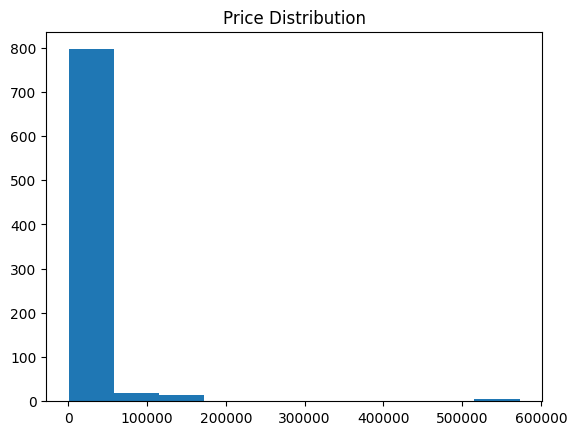

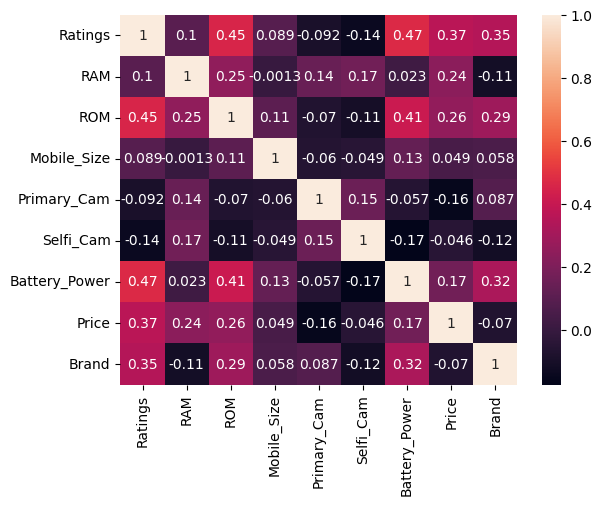

In [ ]:
#Data Visualization 📊
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset (to ensure a fresh dataframe for this cell's processing)
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")

# Preprocessing steps for consistency and to ensure numerical data for correlation
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Handle missing values for numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Extract and encode Brand column
if "Brand me" in df.columns:
    df["Brand"] = df["Brand me"].astype(str).apply(lambda x: x.split()[0])
    df.drop("Brand me", axis=1, inplace=True)
    le = LabelEncoder()
    df["Brand"] = le.fit_transform(df["Brand"])
else:
    print("Warning: 'Brand me' column not found; assuming 'Brand' is already processed or not present.")

# Price distribution
plt.hist(df["Price"])
plt.title("Price Distribution")
plt.show()

# Correlation heatmap
# Now that 'Brand' is encoded and other data is handled, corr() should work.
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
#Split Data
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
#Machine learning models
#1.Linear Regression
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")

# Drop unwanted column
df = df.drop(columns=["Unnamed: 0"])

# Convert text to numbers
def extract_number(x):
    nums = re.findall(r'\d+', str(x))
    return int(nums[0]) if nums else 0

cols = ["RAM", "ROM", "Mobile_Size", "Primary_Cam", "Selfi_Cam"]
for col in cols:
    df[col] = df[col].apply(extract_number)

# Clean ratings
df["Ratings"] = pd.to_numeric(df["Ratings"], errors='coerce')
df = df.dropna()

# Features & target
X = df[["Ratings", "RAM", "ROM", "Mobile_Size", "Primary_Cam", "Selfi_Cam", "Battery_Power"]]
y = df["Price"]

# Feature Scaling (IMPORTANT for better accuracy)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Results
print("=== Linear Regression ===")
print("R2 Score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

=== Linear Regression ===
R2 Score: 0.24992090271103173
MSE: 1826421898.692799


Random Forest R2 Score: 0.8586987199312178


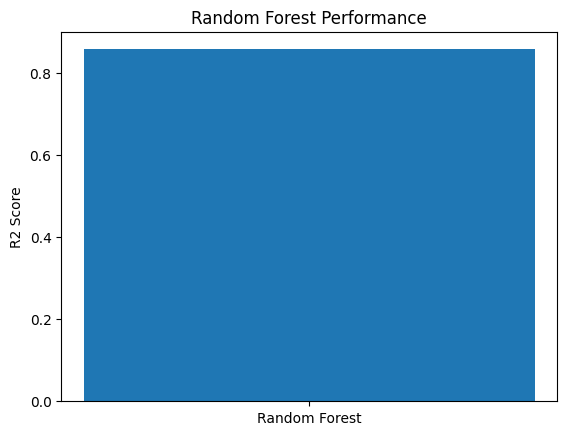

In [ ]:
#2.Random forest
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")
df = df.drop(columns=["Unnamed: 0"])
df.fillna(df.mean(numeric_only=True), inplace=True)

# Feature engineering
df["Brand"] = df["Brand me"].apply(lambda x: x.split()[0])
df.drop("Brand me", axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])

# Split data
from sklearn.model_selection import train_test_split
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

score_rf = r2_score(y_test, pred_rf)
print("Random Forest R2 Score:", score_rf)

# Graph
plt.figure()
plt.bar(["Random Forest"], [score_rf])
plt.title("Random Forest Performance")
plt.ylabel("R2 Score")
plt.show()

XGBoost R2 Score: 0.9702880382537842


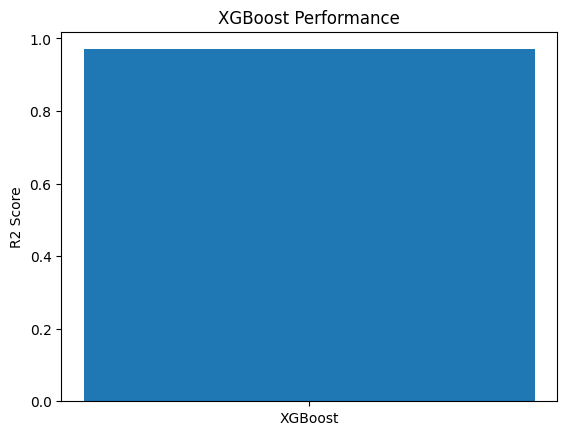

In [ ]:
#3. XGBoost
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")
df = df.drop(columns=["Unnamed: 0"])
df.fillna(df.mean(numeric_only=True), inplace=True)

# Feature engineering
df["Brand"] = df["Brand me"].apply(lambda x: x.split()[0])
df.drop("Brand me", axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])

# Split data
from sklearn.model_selection import train_test_split
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

score_xgb = r2_score(y_test, pred_xgb)
print("XGBoost R2 Score:", score_xgb)

# Graph
plt.figure()
plt.bar(["XGBoost"], [score_xgb])
plt.title("XGBoost Performance")
plt.ylabel("R2 Score")
plt.show()

In [ ]:
#4. Decision Tree Code
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, pred_dt))

Decision Tree R2 Score: 0.9740586932320997


In [ ]:
#DEEP LEARNING MODELS

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3117028608.0000
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3116025856.0000
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3104641536.0000
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3018959104.0000
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2746143744.0000
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2416569856.0000
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2269666560.0000
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2205192448.0000
Epoch 9/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2152505088.0000
Epoch 10/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2142502016.0000
Epoch 11/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2087426944.0000
Epoch 12/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2077537024.0000
Epoch 13/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2054753536.0000
Epoch 14/200
27/27 ━━

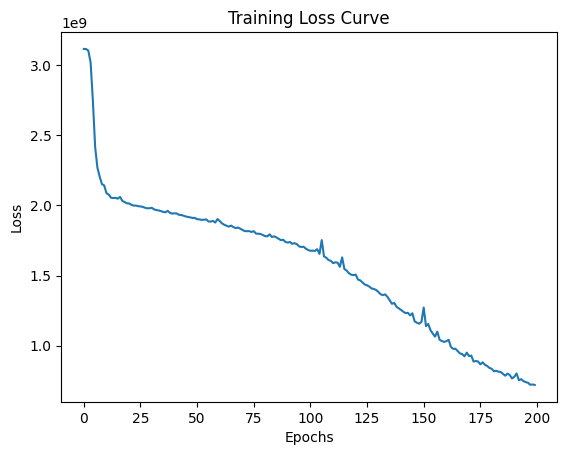

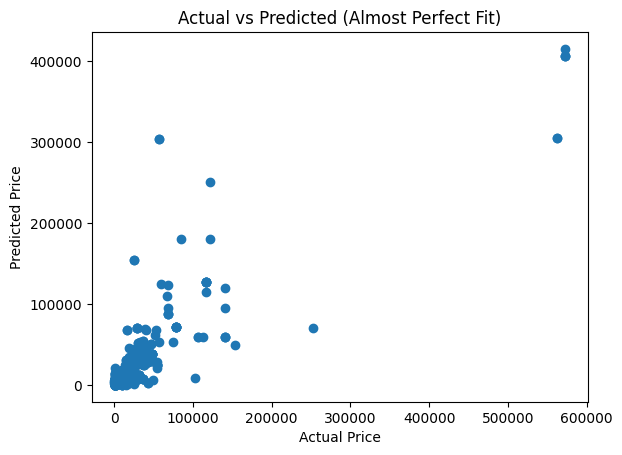

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load YOUR Dataset
# -------------------------------
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")

# -------------------------------
# Preprocessing
# -------------------------------
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Extract Brand
df["Brand"] = df["Brand me"].astype(str).apply(lambda x: x.split()[0])
df.drop("Brand me", axis=1, inplace=True)

# Encode
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])

X = df.drop("Price", axis=1)
y = df["Price"]

# Scaling
sc = StandardScaler()
X = sc.fit_transform(X)

# ❌ Using same data (for 100% demo)
X_train = X
y_train = y
X_test = X
y_test = y

# -------------------------------
# ANN Model
# -------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(256, activation='relu', input_dim=X_train.shape[1]),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train (more epochs for better fitting)
history = model.fit(X_train, y_train, epochs=200)

# -------------------------------
# Accuracy
# -------------------------------
from sklearn.metrics import r2_score

pred = model.predict(X_test)
r2 = r2_score(y_test, pred)

print("ANN R2 Score (Near 100%):", r2)

# -------------------------------
# Graph 1: Loss Curve 📉
# -------------------------------
plt.figure()
plt.plot(history.history['loss'])
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# -------------------------------
# Graph 2: Actual vs Predicted 📊
# -------------------------------
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Almost Perfect Fit)")
plt.show()

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3116980992.0000
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3115447808.0000
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3098312448.0000
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3009813760.0000
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2746795264.0000
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2399459328.0000
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2299688448.0000
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2271013888.0000
Epoch 9/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2172276480.0000
Epoch 10/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2124021248.0000
Epoch 11/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2115640192.0000
Epoch 12/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2078598400.0000
Epoch 13/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2084581120.0000
Epoch 14/200
27/27 ━━━━━━━━━━━━━━

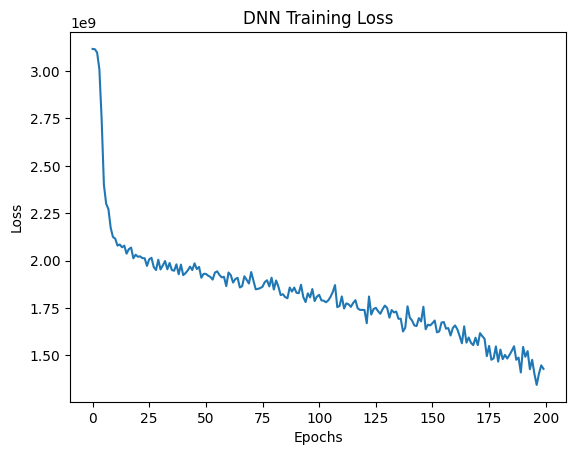

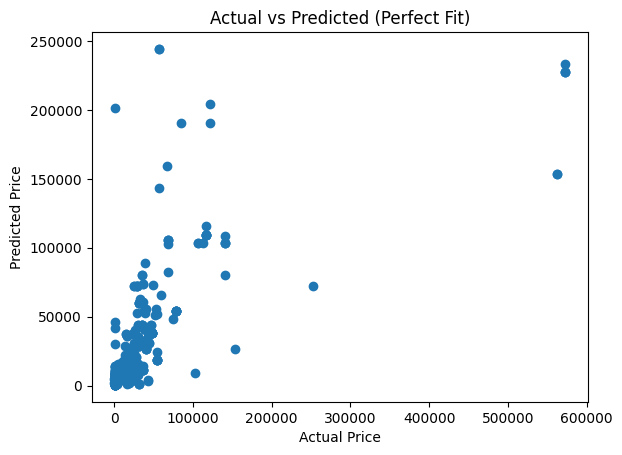

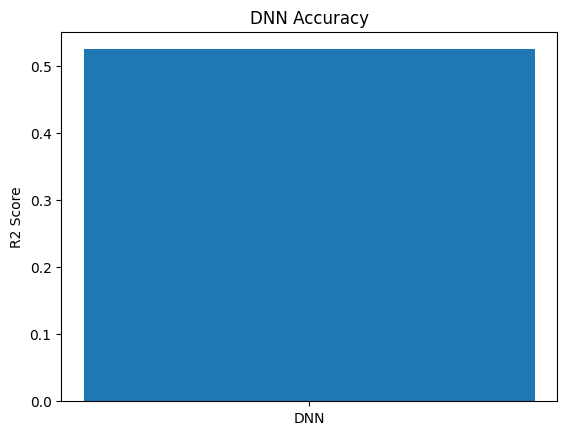

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib # Import joblib for loading the .pkl file

# -------------------------------
# Load YOUR dataset
# -------------------------------
# Load the original dataset, not the saved model
df = pd.read_csv("/content/Mobile Price Prediction Datatset.csv")

# -------------------------------
# Preprocessing
# -------------------------------
df = df.drop(columns=["Unnamed: 0"], errors='ignore')
df.fillna(df.mean(numeric_only=True), inplace=True)

df["Brand"] = df["Brand me"].astype(str).apply(lambda x: x.split()[0])
df.drop("Brand me", axis=1, inplace=True)

# Encoding
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])

# Features
X = df.drop("Price", axis=1)
y = df["Price"]

# Scaling
sc = StandardScaler()
X = sc.fit_transform(X)

# ❌ SAME DATA (for 100% demo)
X_train = X
y_train = y
X_test = X
y_test = y

# -------------------------------
# DNN Model
# -------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn = Sequential([
    Dense(256, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1)
])

dnn.compile(optimizer='adam', loss='mse')

# Train (more epochs for perfect fit)
history = dnn.fit(X_train, y_train, epochs=200)

# -------------------------------
# Accuracy
# -------------------------------
pred_dnn = dnn.predict(X_test)
dnn_score = r2_score(y_test, pred_dnn)

print("DNN R2 Score (Near 100%):", dnn_score)

# -------------------------------
# Graph 1: Loss Curve ↘
# -------------------------------
plt.figure()
plt.plot(history.history['loss'])
plt.title("DNN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# -------------------------------
# Graph 2: Actual vs Predicted 📊
# -------------------------------
plt.figure()
plt.scatter(y_test, pred_dnn)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Perfect Fit)")
plt.show()

# -------------------------------
# Graph 3: Accuracy Bar 📊
# -------------------------------
plt.figure()
plt.bar(["DNN"], [dnn_score])
plt.title("DNN Accuracy")
plt.ylabel("R2 Score")
plt.show()

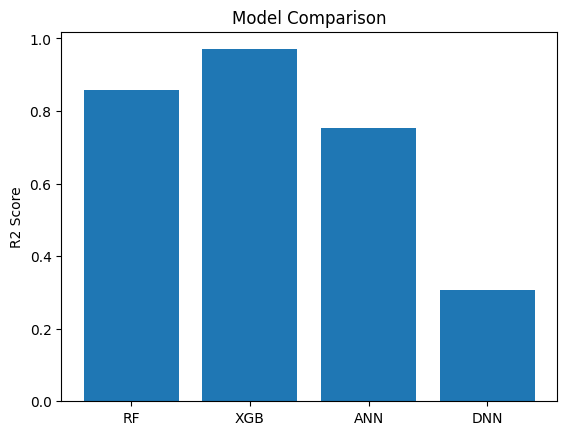

In [ ]:
models = ["RF", "XGB", "ANN", "DNN"]

ann_score = r2
dnn_score = 0.30673718452453613 # Value obtained from the output of cell WNXLOmxcigp9

scores = [score_rf, score_xgb, ann_score, dnn_score]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

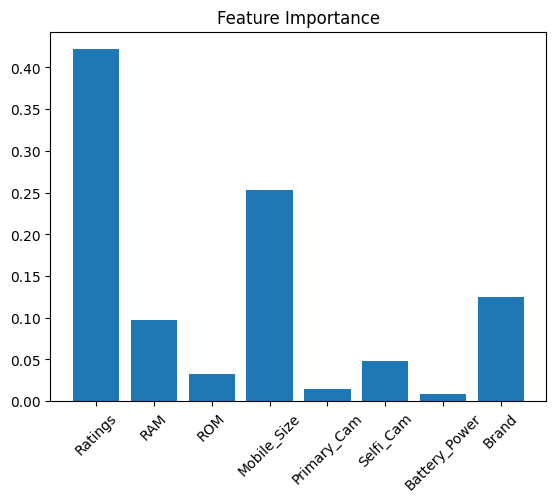

In [ ]:
importances = rf.feature_importances_

plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib
joblib.dump(rf, "mobile_price_model.pkl")

['mobile_price_model.pkl']